# Dataset preprocessing

* Dividing the features into area, thickness and volume features.
* Removing features that are linearly dependent on others.
* Remove subjects younger than 50 years old.
* Combine left and right hemisphere features
* Assign a test fold for each subject, ensuring that all timepoints of a subject are in the same fold.
* Create slope variables for each feature, representing the change in the feature over time.
* z-score all features, slope and intercept variables using the full sample statistics (current implementation).


In [70]:
import warnings
from pathlib import Path

import matplotlib.pyplot as plt
import numpy as np
import pandas as pd
import seaborn as sns
from statsmodels.tools.sm_exceptions import ConvergenceWarning
from pandas.errors import PerformanceWarning

# Centralized paths for reproducible I/O
DATA_DIR = Path("/fp/projects01/ec201/userdata/ec-edvardsg/reconsider_brain_age")
# Create the data directory if it doesn't exist
DATA_DIR.mkdir(parents=True, exist_ok=True)

INPUT_CSV = DATA_DIR / "brain_age_data_all.csv"
OUTPUT_CSV = DATA_DIR / "brain_age_data_processed.csv"
FEATURES_JSON = DATA_DIR / "features.json"

# Keep notebook output compact by suppressing noisy, non-actionable warnings
warnings.filterwarnings("ignore", category=FutureWarning)
warnings.filterwarnings("ignore", category=PerformanceWarning)
warnings.filterwarnings("ignore", category=ConvergenceWarning)
warnings.filterwarnings("ignore", category=pd.errors.SettingWithCopyWarning)

df = pd.read_csv(INPUT_CSV)

print(f"Initial shape of the dataframe: {df.shape}")

Initial shape of the dataframe: (56669, 263)


/tmp/ipykernel_3025590/1501603327.py:26: DtypeWarning: Columns (262) have mixed types. Specify dtype option on import or set low_memory=False.
  df = pd.read_csv(INPUT_CSV)


In [71]:
df.head()

,index,dataset,age,sex_female,site,sitenum,Dx,lh_bankssts_volume,lh_caudalanteriorcingulate_volume,lh_caudalmiddlefrontal_volume,...,eduT,EduC3,EduC2,edu.scale,edu.demean,edu.res3,EduSplit,bw,esttau,groupTAU
0,0,adni,54.6,0.0,adni_073-avanto,1000108.0,1.0,2060.0,2392.0,5975.0,...,20.0,3.0,2.0,1.434872,3.956049,1.223949,1.0,NaN,NaN,NaN
1,1,adni,55.1,1.0,adni_016-skyra,1000034.0,0.0,2879.0,1180.0,5070.0,...,18.0,3.0,2.0,0.709465,1.956049,0.873491,1.0,NaN,1.155504,TAU_neg
2,2,adni,55.1,1.0,adni_035-triotim,1000075.0,1.0,2383.0,2161.0,5995.0,...,14.0,2.0,1.0,-0.741348,-2.043951,-0.752532,0.0,NaN,1.246675,TAU_delta
3,3,adni,55.1,1.0,adni_037-triotim,1000081.0,1.0,1843.0,1269.0,6093.0,...,17.0,3.0,2.0,0.346762,0.956049,0.369080,1.0,NaN,NaN,NaN
4,4,adni,55.2,1.0,adni_137-signa,1000161.0,1.0,1639.0,1286.0,4411.0,...,18.0,3.0,2.0,0.709465,1.956049,0.684532,1.0,NaN,NaN,NaN


In [72]:
# Count rows per dataset
dataset_counts = df["dataset"].value_counts()
print("Number of rows in each dataset:")
print(dataset_counts)

Number of rows in each dataset:
dataset
ukb_sc       43355
adni          5985
ukb           2578
uio           1737
preventad     1367
dlbs           952
habs           695
Name: count, dtype: int64


In [73]:
# Check for duplicate rids across ukb and ukb_sc
ukb_rids = set(df[df['dataset'] == 'ukb']['rid'])
ukb_sc_rids = set(df[df['dataset'] == 'ukb_sc']['rid'])
duplicate_rids = ukb_rids.intersection(ukb_sc_rids)
print(f"Number of duplicate rids between ukb and ukb_sc: {len(duplicate_rids)}")

Number of duplicate rids between ukb and ukb_sc: 0


## Keep subjects with age between 50 and 90 years (inclusive)

<Axes: >

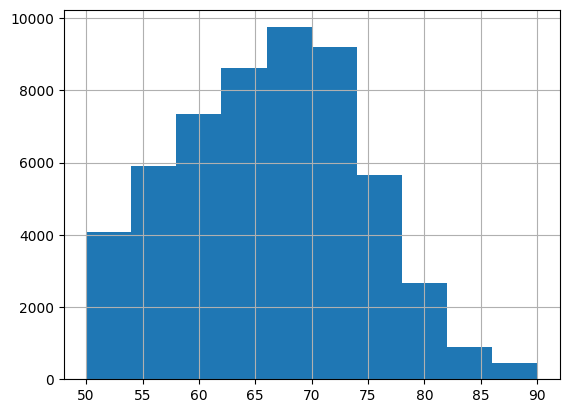

In [74]:
df = df[(df['age'] >= 50) & (df['age'] <= 90)]
df['age'].hist()

## Combine left and right hemisphere features

In [75]:
not_features = ["index", "dataset", "age", "sex_female", "site", "sitenum", "Dx", "timepoint", "agebl", "time", "total_tp_mri", "rid", "eduT", "EduC3", "EduC2", "edu.scale", "edu.demean", "edu.res3", "EduSplit", "bw", "minage", "maxage", "estaget0", "estdtt0", "esttau", "fu_time_to_pos", "bl_time_to_pos", "groupTAU", "pacni"]
features = [f for f in df.columns if f not in not_features]
print(f"Number of candidate features: {len(features)}")
print("First 20 feature names:", features[:20])

Number of candidate features: 241
First 20 feature names: ['lh_bankssts_volume', 'lh_caudalanteriorcingulate_volume', 'lh_caudalmiddlefrontal_volume', 'lh_cuneus_volume', 'lh_entorhinal_volume', 'lh_frontalpole_volume', 'lh_fusiform_volume', 'lh_inferiorparietal_volume', 'lh_inferiortemporal_volume', 'lh_insula_volume', 'lh_isthmuscingulate_volume', 'lh_lateraloccipital_volume', 'lh_lateralorbitofrontal_volume', 'lh_lingual_volume', 'lh_medialorbitofrontal_volume', 'lh_middletemporal_volume', 'lh_paracentral_volume', 'lh_parahippocampal_volume', 'lh_parsopercularis_volume', 'lh_parsorbitalis_volume']


In [76]:
# Combine left/right hemisphere features by summing matched pairs.
# Keep unmatched features and print only a compact warning summary.
total_features = []
missing_pairs = []

for feature in features:
    if feature.startswith(("lh_", "Left-")):
        left_feature = feature
        if feature.startswith("lh_"):
            right_feature = left_feature.replace("lh_", "rh_")
        else:
            right_feature = left_feature.replace("Left-", "Right-")

        if right_feature in df.columns:
            combined_feature = df[left_feature] + df[right_feature]
            total_name = left_feature.replace("lh_", "").replace("Left-", "")
            combined_feature.name = total_name
            total_features.append(combined_feature.name)
            df[combined_feature.name] = combined_feature
        else:
            missing_pairs.append((left_feature, right_feature))
    elif feature.startswith(("rh_", "Right-")):
        continue
    else:
        total_features.append(feature)

df = df.copy()
print(f"Total features after hemisphere combination: {len(total_features)}")
if missing_pairs:
    print(f"Missing right-hemisphere matches: {len(missing_pairs)}")
    print("Examples:", missing_pairs[:10])

Total features after hemisphere combination: 125


In [77]:
print(f"Final feature count: {len(total_features)}")
print("First 20 features:", total_features[:20])
features = total_features

Final feature count: 125
First 20 features: ['bankssts_volume', 'caudalanteriorcingulate_volume', 'caudalmiddlefrontal_volume', 'cuneus_volume', 'entorhinal_volume', 'frontalpole_volume', 'fusiform_volume', 'inferiorparietal_volume', 'inferiortemporal_volume', 'insula_volume', 'isthmuscingulate_volume', 'lateraloccipital_volume', 'lateralorbitofrontal_volume', 'lingual_volume', 'medialorbitofrontal_volume', 'middletemporal_volume', 'paracentral_volume', 'parahippocampal_volume', 'parsopercularis_volume', 'parsorbitalis_volume']


## Remove features that are linearly dependent on others or not supported by all datasets

In [78]:
# Remove SupraTentorialVolNotVent from the feature list.
# This mirrors the current analysis choices in this notebook.
features.remove("SupraTentorialVolNotVent")

features.remove("temporalpole_thickness")
features.remove("temporalpole_area")
features.remove("temporalpole_volume")


## Get the features and divide them into area, thickness and volume features

In [79]:
print(list(df.columns))

['index', 'dataset', 'age', 'sex_female', 'site', 'sitenum', 'Dx', 'lh_bankssts_volume', 'lh_caudalanteriorcingulate_volume', 'lh_caudalmiddlefrontal_volume', 'lh_cuneus_volume', 'lh_entorhinal_volume', 'lh_frontalpole_volume', 'lh_fusiform_volume', 'lh_inferiorparietal_volume', 'lh_inferiortemporal_volume', 'lh_insula_volume', 'lh_isthmuscingulate_volume', 'lh_lateraloccipital_volume', 'lh_lateralorbitofrontal_volume', 'lh_lingual_volume', 'lh_medialorbitofrontal_volume', 'lh_middletemporal_volume', 'lh_paracentral_volume', 'lh_parahippocampal_volume', 'lh_parsopercularis_volume', 'lh_parsorbitalis_volume', 'lh_parstriangularis_volume', 'lh_pericalcarine_volume', 'lh_postcentral_volume', 'lh_posteriorcingulate_volume', 'lh_precentral_volume', 'lh_precuneus_volume', 'lh_rostralanteriorcingulate_volume', 'lh_rostralmiddlefrontal_volume', 'lh_superiorfrontal_volume', 'lh_superiorparietal_volume', 'lh_superiortemporal_volume', 'lh_supramarginal_volume', 'lh_temporalpole_volume', 'lh_trans

In [80]:
area_features = [f for f in features if 'area' in f]
print(area_features)
thickness_features = [f for f in features if 'thickness' in f]
print(thickness_features)
volume_features = [f for f in features if f not in area_features + thickness_features]
print(volume_features)

['bankssts_area', 'caudalanteriorcingulate_area', 'caudalmiddlefrontal_area', 'cuneus_area', 'entorhinal_area', 'frontalpole_area', 'fusiform_area', 'inferiorparietal_area', 'inferiortemporal_area', 'insula_area', 'isthmuscingulate_area', 'lateraloccipital_area', 'lateralorbitofrontal_area', 'lingual_area', 'medialorbitofrontal_area', 'middletemporal_area', 'paracentral_area', 'parahippocampal_area', 'parsopercularis_area', 'parsorbitalis_area', 'parstriangularis_area', 'pericalcarine_area', 'postcentral_area', 'posteriorcingulate_area', 'precentral_area', 'precuneus_area', 'rostralanteriorcingulate_area', 'rostralmiddlefrontal_area', 'superiorfrontal_area', 'superiorparietal_area', 'superiortemporal_area', 'supramarginal_area', 'transversetemporal_area', 'Accumbens-area']
['bankssts_thickness', 'caudalanteriorcingulate_thickness', 'caudalmiddlefrontal_thickness', 'cuneus_thickness', 'entorhinal_thickness', 'frontalpole_thickness', 'fusiform_thickness', 'inferiorparietal_thickness', 'i

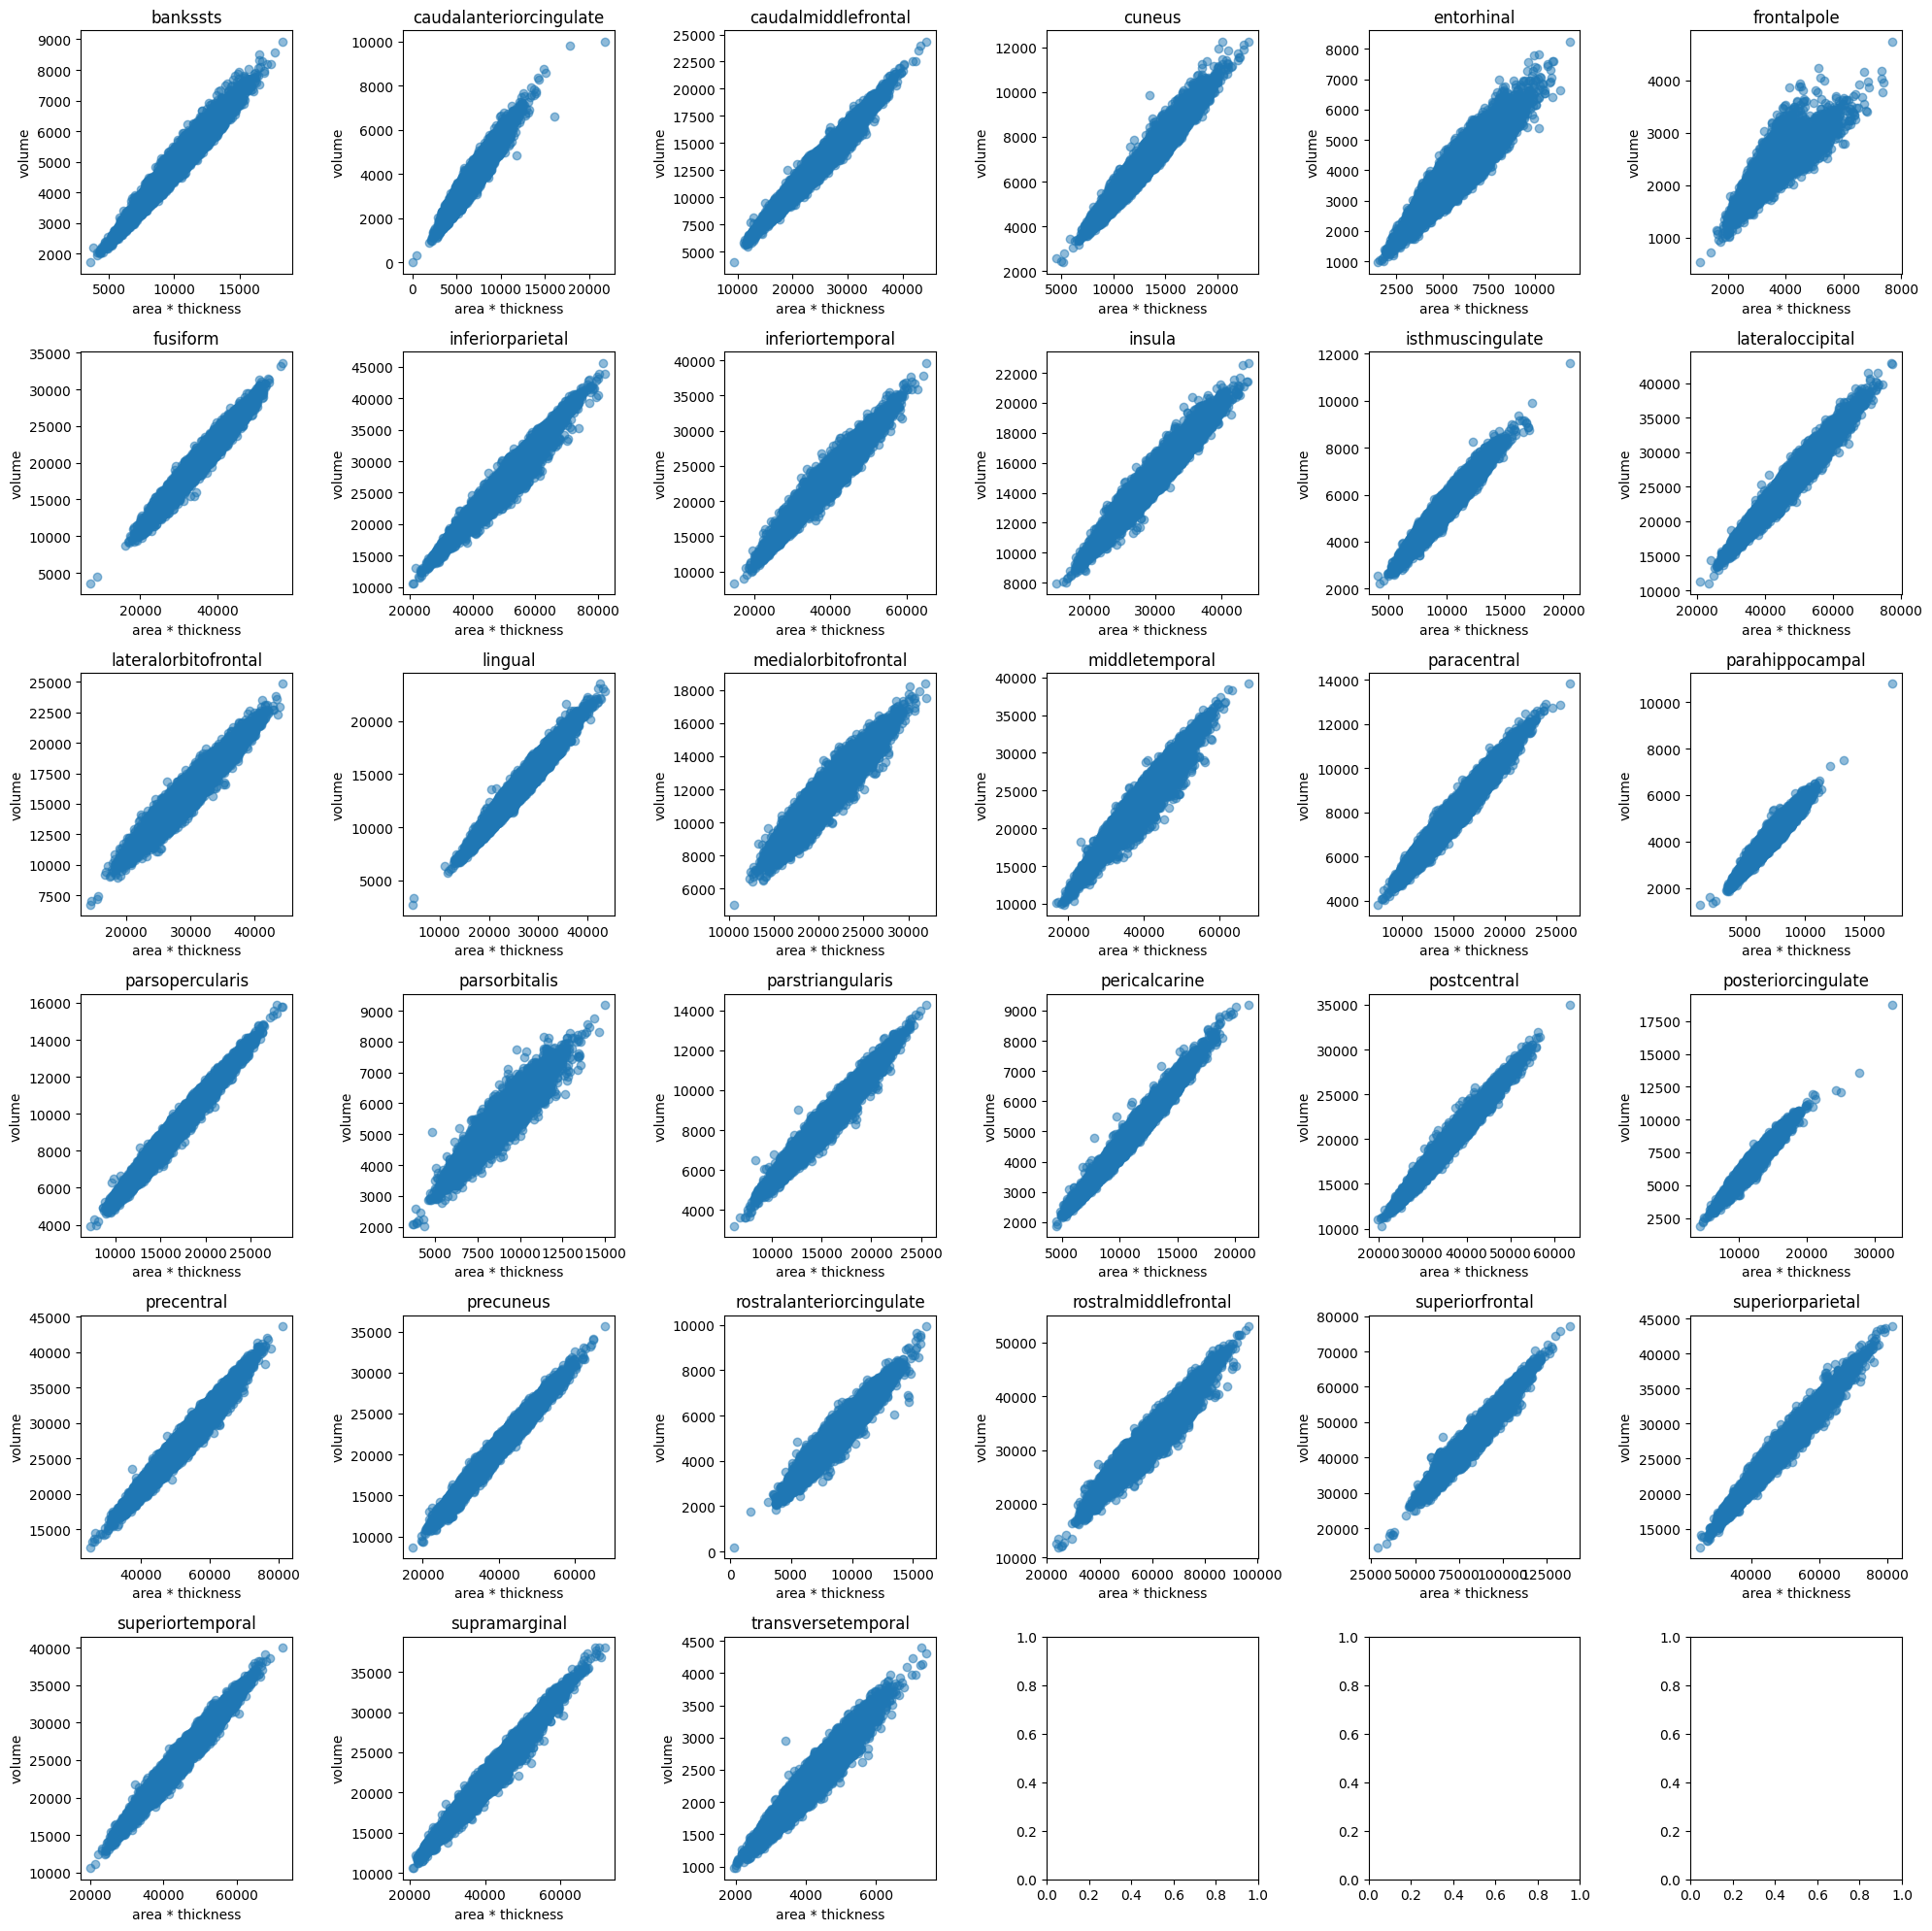

In [81]:
# Check for linear dependencies between features
corr_matrix = df[features].corr().abs()

n_cols = 6
n_rows = int(np.ceil(len(area_features) / n_cols))

fig, axes = plt.subplots(n_rows, n_cols, figsize=(20, 20))
axes = axes.flatten()
#Plot area*thickness against volume features to check for linear dependencies
for ax, area, thickness, volume in zip(axes, area_features, thickness_features, volume_features):
    name = area.replace('_area', '')
    ax.scatter(df[area] * df[thickness], df[volume], alpha=0.5)
    ax.set_xlabel(f"area * thickness")
    ax.set_ylabel(f"volume") 
    ax.set_title(name)
plt.tight_layout()
    


## Site bias correction


In [82]:
# feature ~ s(age) + site + (age|rid)
# Useing statsmodel to fit a mixed effects model to extract the slope and intercept for each subject
import statsmodels.api as sm
import statsmodels.formula.api as smf

# Bias correct the feature by regressing out ICV and site but keeping the age effect

# z-score ICV
df['EstimatedTotalIntraCranialVol_z'] = (df['EstimatedTotalIntraCranialVol'] - df['EstimatedTotalIntraCranialVol'].mean()) / df['EstimatedTotalIntraCranialVol'].std()

df_corrected = df.copy()
for f_idx, feature in enumerate(features):
    print(f"Correcting feature: {feature} ({f_idx+1}/{len(features)})")
    model = smf.ols(
        f"Q('{feature}') ~ cr(age, df=5) + C(site) + EstimatedTotalIntraCranialVol_z",
        data=df,
    )
    result = model.fit()
    params = result.params

    site_cols = [c for c in params.index if "C(site)" in c]
    icv_col = "EstimatedTotalIntraCranialVol_z"

    nuisance = (
        df[icv_col] * params[icv_col]
    )

    df_corrected[f"{feature}_icv_corr"] = df[feature] - nuisance
    
    site_nuisance = np.zeros(len(df))

    for col in site_cols:
        level = col.split("[T.")[-1].rstrip("]")
        site_nuisance += (df["site"] == level).astype(float) * params[col]

    df_corrected[f"{feature}_site_corr"] = df[feature] - site_nuisance
    
    df_corrected[f"{feature}_corr"] = df[feature] - nuisance - site_nuisance
        
        


Correcting feature: bankssts_volume (1/121)
Correcting feature: caudalanteriorcingulate_volume (2/121)
Correcting feature: caudalmiddlefrontal_volume (3/121)
Correcting feature: cuneus_volume (4/121)
Correcting feature: entorhinal_volume (5/121)
Correcting feature: frontalpole_volume (6/121)
Correcting feature: fusiform_volume (7/121)
Correcting feature: inferiorparietal_volume (8/121)
Correcting feature: inferiortemporal_volume (9/121)
Correcting feature: insula_volume (10/121)
Correcting feature: isthmuscingulate_volume (11/121)
Correcting feature: lateraloccipital_volume (12/121)
Correcting feature: lateralorbitofrontal_volume (13/121)
Correcting feature: lingual_volume (14/121)
Correcting feature: medialorbitofrontal_volume (15/121)
Correcting feature: middletemporal_volume (16/121)
Correcting feature: paracentral_volume (17/121)
Correcting feature: parahippocampal_volume (18/121)
Correcting feature: parsopercularis_volume (19/121)
Correcting feature: parsorbitalis_volume (20/121)


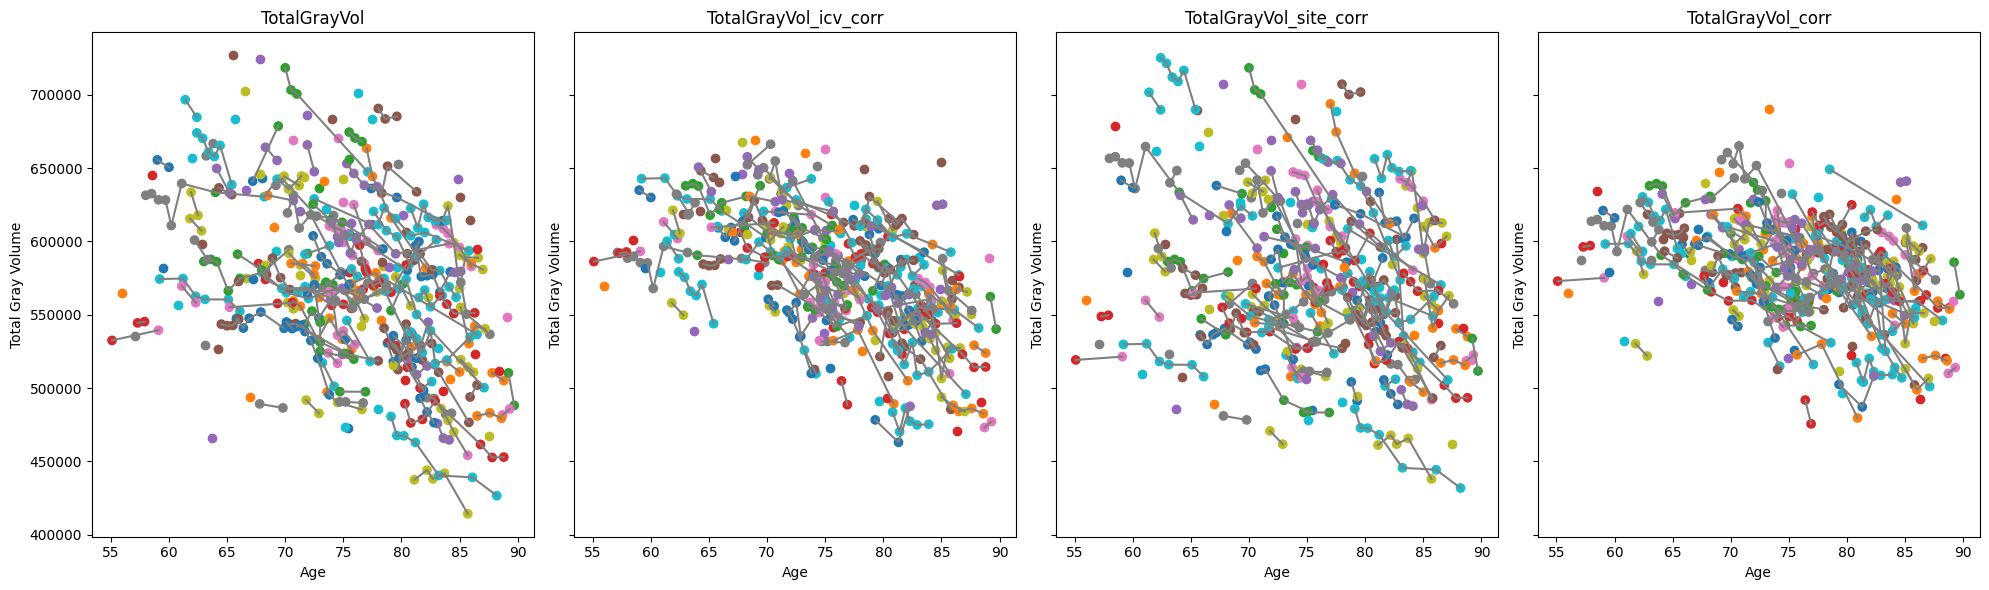

In [83]:
# Plot TotalGrayVol trajectories for random ADNI subjects before/after correction
fig, axs = plt.subplots(1, 4, figsize=(20, 6), sharey=True)
n_subjects = 200
dataset_df = df_corrected[df_corrected["dataset"] == "adni"]
sample_subjects = np.random.choice(dataset_df["rid"].unique(), size=n_subjects, replace=False)
# Get a color for each site
site_colors = {site: color for site, color in zip(dataset_df["site"].unique(), sns.color_palette(n_colors=dataset_df["site"].nunique()))}

for i, feature_postfix in enumerate(["", "_icv_corr", "_site_corr", "_corr"]):
    for rid in sample_subjects:
        subject_data = dataset_df[dataset_df["rid"] == rid]
        sites = subject_data["site"]
        axs[i].plot(subject_data["age"], subject_data[f"TotalGrayVol{feature_postfix}"], marker="", label=f"rid: {rid}", color="gray")
        axs[i].scatter(subject_data["age"], subject_data[f"TotalGrayVol{feature_postfix}"], color=sites.map(site_colors), label=f"rid: {rid}")
    axs[i].set_title(f"TotalGrayVol{feature_postfix}")
    axs[i].set_xlabel("Age")
    axs[i].set_ylabel("Total Gray Volume")
    
    # Create a legend for the sites
#    handles = [plt.Line2D([0], [0], marker='o', color='w', label=site, markerfacecolor=color, markersize=10) for site, color in site_colors.items()]
#    axs[i].legend(handles=handles, title='Site', bbox_to_anchor=(1.05, 1), loc='upper left')
plt.tight_layout()

In [84]:
df = df_corrected.copy()

## Create subject-level test folds for all subjects

In [85]:
kfolds = 5
subjects = df['rid'].unique()
np.random.seed(42)
test_folds = np.random.choice(kfolds, size=len(subjects), replace=True)
test_fold_dict = dict(zip(subjects, test_folds))
df['test_fold'] = df['rid'].map(test_fold_dict)

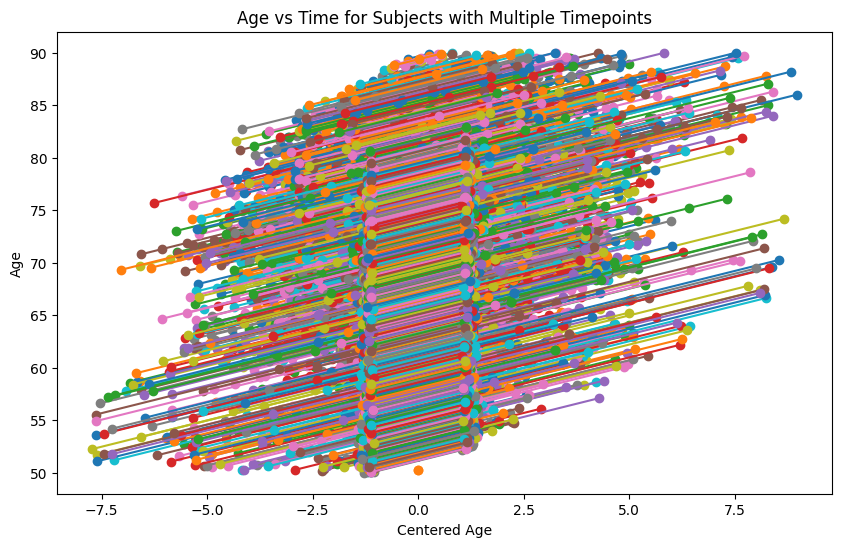

In [86]:

df['age_mean'] = df.groupby('rid')['age'].transform('mean')
df['age_centered'] = df['age'] - df['age_mean']
fig, ax = plt.subplots(figsize=(10, 6))
for rid, group in df.groupby('rid'):
    if len(group) > 1:
        ax.plot(group['age_centered'], group['age'], marker='o')
ax.set_xlabel('Centered Age')
ax.set_ylabel('Age')
ax.set_title('Age vs Time for Subjects with Multiple Timepoints')
plt.show()

## Create the slope and intercept variables for each feature

In [87]:
import statsmodels.api as sm

slopes = {}
intercepts = {}

# Create a df for subjects with multiple timepoints
multi_timepoint_df = df.groupby('rid').filter(lambda x: len(x) > 1)

for idx, (rid, group) in enumerate(multi_timepoint_df.groupby('rid')):
    if idx % 1000 == 0:
        print(f"Processing subject {idx+1}/{len(multi_timepoint_df['rid'].unique())} (rid: {rid})")
    X = group['age_centered']
    y = group[[f"{feature}_site_corr" for feature in features]]
    X = sm.add_constant(X)  # Add a constant term for the intercept
    model = sm.OLS(y, X).fit()
    
    slopes[rid] = model.params.loc['age_centered']
    intercepts[rid] = model.params.loc['const']
    

Processing subject 1/5211 (rid: 0)
Processing subject 1001/5211 (rid: 1234)
Processing subject 2001/5211 (rid: 4359)
Processing subject 3001/5211 (rid: 6787)
Processing subject 4001/5211 (rid: 17047)
Processing subject 5001/5211 (rid: 43305)


In [88]:
int_feature_slope_map = {i: feature + "_slope" for i, feature in enumerate(features)}
int_feature_intercept_map = {i: feature + "_intercept" for i, feature in enumerate(features)}


df_slopes = pd.DataFrame(slopes, columns=slopes.keys()).T.rename(columns=int_feature_slope_map)
# Create a column for rid in df_slopes
df_slopes['rid'] = df_slopes.index
df_intercepts = pd.DataFrame(intercepts, columns=intercepts.keys()).T.rename(columns=int_feature_intercept_map)
# Create a column for rid in df_intercepts
df_intercepts['rid'] = df_intercepts.index
df_merged = df.merge(df_slopes, on='rid', how='left') 
df_merged = df_merged.merge(df_intercepts, on='rid', how='left')


df_merged.head()

,index,dataset,age,sex_female,site,sitenum,Dx,lh_bankssts_volume,lh_caudalanteriorcingulate_volume,lh_caudalmiddlefrontal_volume,...,Amygdala_intercept,CSF_intercept,Accumbens-area_intercept,VentralDC_intercept,vessel_intercept,choroid-plexus_intercept,SubCortGrayVol_intercept,TotalGrayVol_intercept,SupraTentorialVol_intercept,EstimatedTotalIntraCranialVol_intercept
0,0,adni,54.6,0.0,adni_073-avanto,1000108.0,1.0,2060.0,2392.0,5975.0,...,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN
1,1,adni,55.1,1.0,adni_016-skyra,1000034.0,0.0,2879.0,1180.0,5070.0,...,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN
2,2,adni,55.1,1.0,adni_035-triotim,1000075.0,1.0,2383.0,2161.0,5995.0,...,3084.996628,1136.969811,944.620858,7413.403076,181.569814,2014.253812,53156.682831,579716.377619,915193.004353,1.468396e+06
3,3,adni,55.1,1.0,adni_037-triotim,1000081.0,1.0,1843.0,1269.0,6093.0,...,3251.102404,1188.881191,887.826610,7063.641820,141.824549,2230.082173,49942.840867,520281.351455,863825.180466,1.368502e+06
4,4,adni,55.2,1.0,adni_137-signa,1000161.0,1.0,1639.0,1286.0,4411.0,...,2461.063428,1125.840608,891.784873,6162.602492,96.817891,2948.678175,48813.515943,518796.481034,819523.443765,1.352222e+06


In [89]:
df = df_merged.copy()

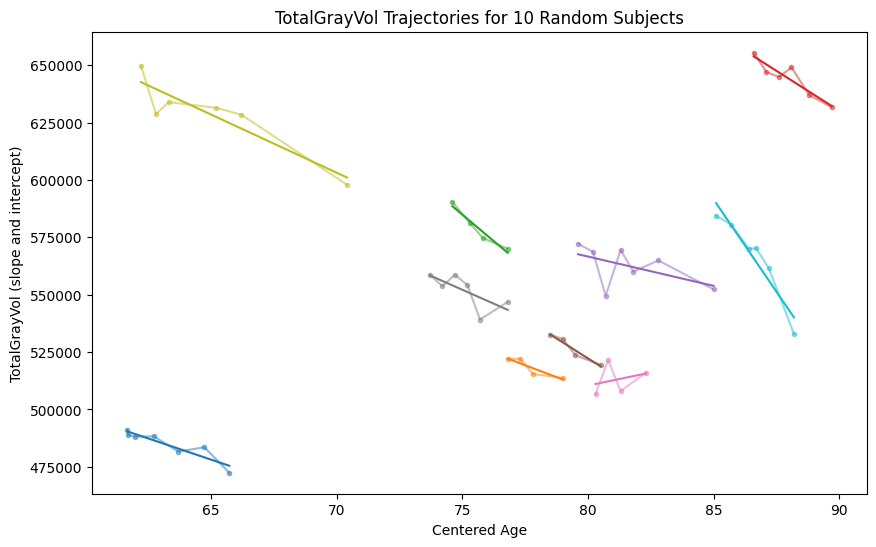

In [90]:
# Pick 10 subjects with >=4 timepoints and visualize slope/intercept fits for one feature

many_timepoints_df = df.groupby("rid").filter(lambda x: len(x) >= 4)
sample_subjects = np.random.choice(many_timepoints_df["rid"].unique(), size=10, replace=False)
feature = "TotalGrayVol"
fig, ax = plt.subplots(figsize=(10, 6))
for rid in sample_subjects:
    subject_data = df[df["rid"] == rid]
    slope = subject_data[f"{feature}_slope"].values[0]
    intercept = subject_data[f"{feature}_intercept"].values[0]
    x_plot = np.array([subject_data["age"].min(), subject_data["age"].max()])
    x = x_plot - subject_data["age_mean"].values[0]  # Center the x values
    y = intercept + slope * x
    plot = ax.plot(x_plot, y, label=f"rid: {rid}")
    
    y_data = subject_data[feature + "_site_corr"].values
    ax.plot(subject_data["age"], y_data, alpha=0.5, marker=".", color=plot[0].get_color())
    
ax.set_xlabel("Centered Age")
ax.set_ylabel(f"{feature} (slope and intercept)")
ax.set_title(f"{feature} Trajectories for 10 Random Subjects")
ax.legend().set_visible(False)

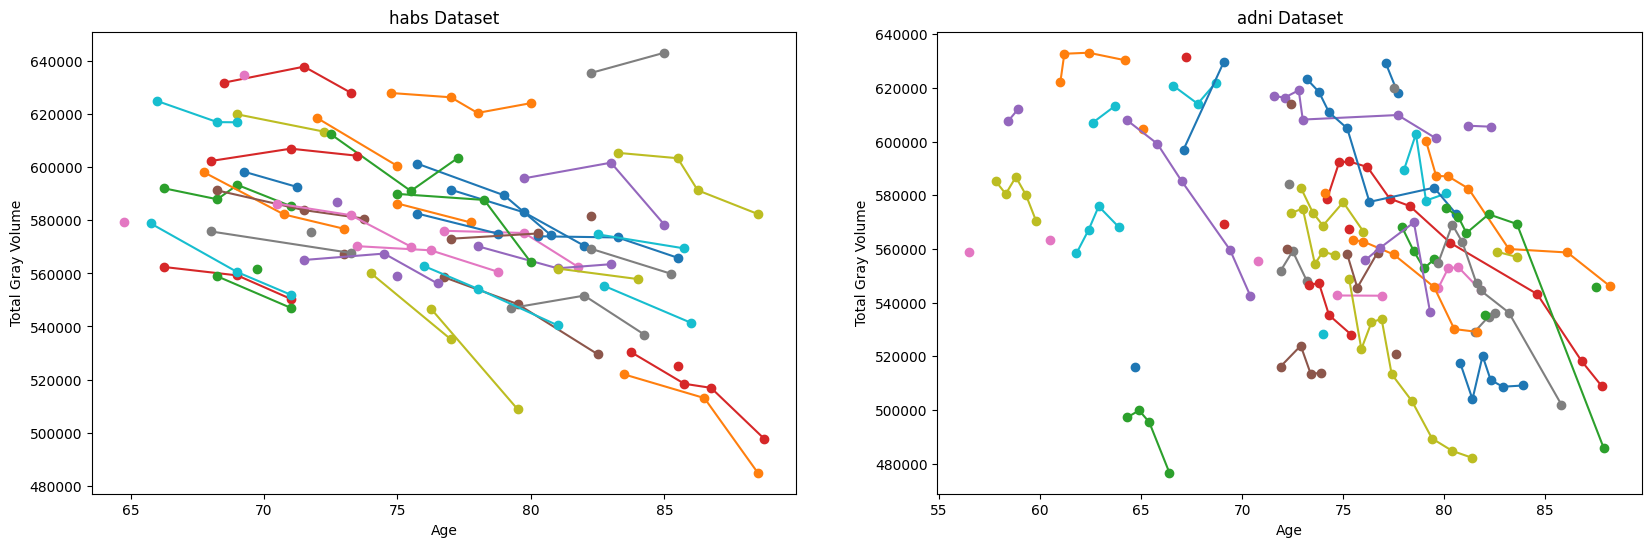

In [91]:
fig, axs = plt.subplots(1, 2, figsize=(20, 6))
n_subjects = 50
for i, dataset in enumerate(['habs', 'adni']):
    dataset_df = df[df['dataset'] == dataset]
    sample_subjects = np.random.choice(dataset_df['rid'].unique(), size=n_subjects, replace=False)
    for rid in sample_subjects:
        subject_data = dataset_df[dataset_df['rid'] == rid]
        axs[i].plot(subject_data['age'], subject_data['TotalGrayVol_corr'], marker='o', label=f"rid: {rid}")
    axs[i].set_title(f'{dataset} Dataset')
    axs[i].set_xlabel('Age')
    axs[i].set_ylabel('Total Gray Volume')
    axs[i].legend().set_visible(False)

<Axes: xlabel='age', ylabel='Lateral-Ventricle_corr'>

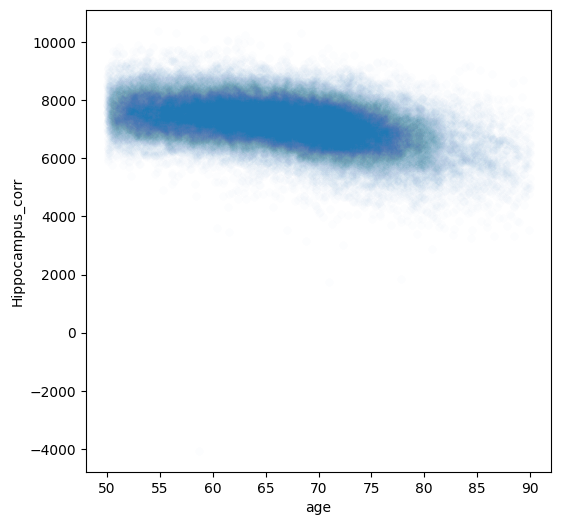

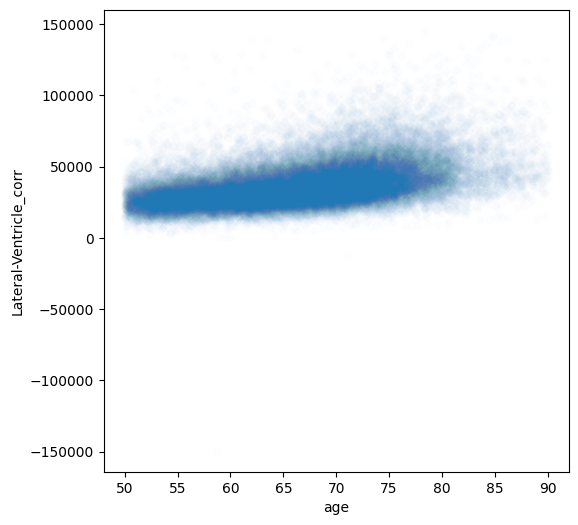

In [92]:
# Plot age vs corrected hippocampus/ventricle features for all subjects
fig, ax = plt.subplots(figsize=(6, 6))
sns.scatterplot(x="age", y="Hippocampus_corr", data=df, alpha=0.01)

fig, ax = plt.subplots(figsize=(6, 6))
sns.scatterplot(x="age", y="Lateral-Ventricle_corr", data=df, alpha=0.01)

In [93]:
# z-score all features including the original features and the corrected features and the slope and intercept
for feature in features:
    df[f"{feature}_z"] = (df[feature] - df[feature].mean()) / df[feature].std()
    df[f"{feature}_icv_corr_z"] = (df[f"{feature}_icv_corr"] - df[f"{feature}_icv_corr"].mean()) / df[f"{feature}_icv_corr"].std()
    df[f"{feature}_site_corr_z"] = (df[f"{feature}_site_corr"] - df[f"{feature}_site_corr"].mean()) / df[f"{feature}_site_corr"].std()
    df[f"{feature}_corr_z"] = (df[f"{feature}_corr"] - df[f"{feature}_corr"].mean()) / df[f"{feature}_corr"].std()
    df[f"{feature}_slope_z"] = (df[f"{feature}_slope"] - df[f"{feature}_slope"].mean()) / df[f"{feature}_slope"].std()
    df[f"{feature}_intercept_z"] = (df[f"{feature}_intercept"] - df[f"{feature}_intercept"].mean()) / df[f"{feature}_intercept"].std()

df = df.copy()



In [94]:
# In the ukb_sc remove all that are not healthy Dx=0
print(f"Shape of the dataframe before removing non-healthy subjects from ukb_sc: {df.shape}")
ukb_sc_cogn_not_helthy = df[(df['dataset'] == 'ukb_sc') & (df['Dx'] != 0)]
df = df[~df['rid'].isin(ukb_sc_cogn_not_helthy['rid'])]
print(f"Shape of the dataframe after removing non-healthy subjects from ukb_sc: {df.shape}")


Shape of the dataframe before removing non-healthy subjects from ukb_sc: (54543, 1713)
Shape of the dataframe after removing non-healthy subjects from ukb_sc: (54543, 1713)


In [95]:
# Save the processed dataframe to CSV
df.to_csv(OUTPUT_CSV, index=False)

In [96]:
print(pd.unique(df['dataset']))

['adni' 'dlbs' 'habs' 'preventad' 'uio' 'ukb' 'ukb_sc']


In [97]:
# Save feature groups to JSON
import json

feature_dict = {
    "features_all": features,
    "area_features": area_features,
    "thickness_features": thickness_features,
    "volume_features": volume_features,
}
with open(FEATURES_JSON, "w") as f:
    json.dump(feature_dict, f)

In [98]:
df.shape

(54543, 1713)

In [99]:
def weighted_correlation(x, y, weights):
    """
    Compute the weighted correlation between two variables x and y with given weights.
    
    Parameters:
    x (array-like): First variable
    y (array-like): Second variable
    weights (array-like): Weights for each observation
    
    Returns:
    float: Weighted correlation coefficient
    """
    # Ensure inputs are numpy arrays
    x = np.asarray(x)
    y = np.asarray(y)
    weights = np.asarray(weights)
    
    # Compute weighted means
    mean_x = np.sum(weights * x) / np.sum(weights)
    mean_y = np.sum(weights * y) / np.sum(weights)
    
    # Compute weighted covariance and variances
    cov_xy = np.sum(weights * (x - mean_x) * (y - mean_y)) / np.sum(weights)
    var_x = np.sum(weights * (x - mean_x) ** 2) / np.sum(weights)
    var_y = np.sum(weights * (y - mean_y) ** 2) / np.sum(weights)
    
    # Compute weighted correlation
    if var_x > 0 and var_y > 0:
        return cov_xy / np.sqrt(var_x * var_y)
    else:
        return 0.0  # Return 0 if either variance is zero to avoid division by zero

In [100]:
# Create a column for the time between the first and last timepoint for each subject
df['time_between_first_last'] = df.groupby('rid')['age'].transform(lambda x: x.max() - x.min())

/tmp/ipykernel_3025590/3720227964.py:19: RuntimeWarning: invalid value encountered in scalar divide
  mean_x = np.sum(weights * x) / np.sum(weights)
/tmp/ipykernel_3025590/3720227964.py:20: RuntimeWarning: invalid value encountered in scalar divide
  mean_y = np.sum(weights * y) / np.sum(weights)
/tmp/ipykernel_3025590/3720227964.py:23: RuntimeWarning: invalid value encountered in scalar divide
  cov_xy = np.sum(weights * (x - mean_x) * (y - mean_y)) / np.sum(weights)
/tmp/ipykernel_3025590/3720227964.py:24: RuntimeWarning: invalid value encountered in scalar divide
  var_x = np.sum(weights * (x - mean_x) ** 2) / np.sum(weights)
/tmp/ipykernel_3025590/3720227964.py:25: RuntimeWarning: invalid value encountered in scalar divide
  var_y = np.sum(weights * (y - mean_y) ** 2) / np.sum(weights)


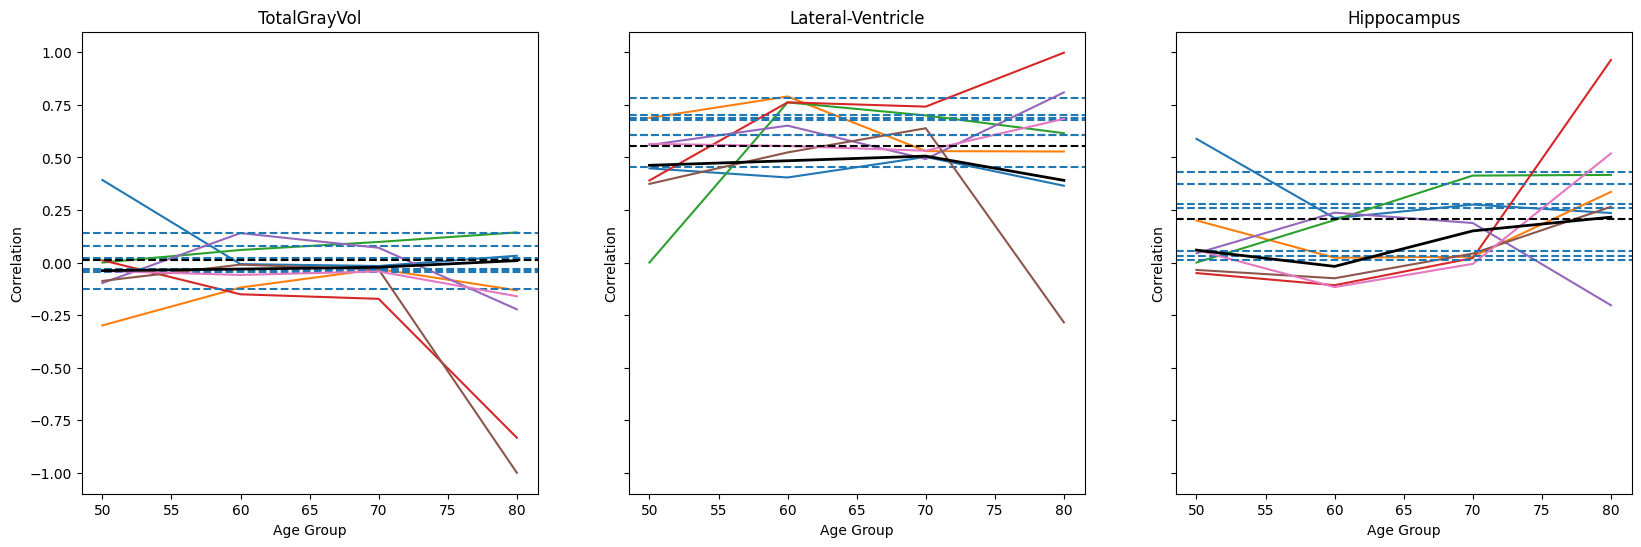

In [101]:
# In 10-year age groups, compute intercept-slope correlations for selected features
features_to_plot = ['TotalGrayVol', 'Lateral-Ventricle', 'Hippocampus']
age_bins = np.arange(50, 95, 10)
df['age_group'] = pd.cut(df['age_mean'], bins=age_bins)

# Get a single session per subject
df_single_subject = df.groupby('rid').first().reset_index()
# Remove subjects with missing slope or intercept values
df_single_subject = df_single_subject.dropna(subset=[f"{feature}_slope" for feature in features_to_plot] + [f"{feature}_intercept" for feature in features_to_plot])

# Remove slope outliers
for feature in features_to_plot:
    slope_col = f"{feature}_slope"
    intercept_col = f"{feature}_intercept"
    slope_mean = df_single_subject[slope_col].mean()
    slope_std = df_single_subject[slope_col].std()
    intercept_mean = df_single_subject[intercept_col].mean()
    intercept_std = df_single_subject[intercept_col].std()
    
    df_single_subject = df_single_subject[
        (df_single_subject[slope_col] >= slope_mean - 3 * slope_std) &
        (df_single_subject[slope_col] <= slope_mean + 3 * slope_std) &
        (df_single_subject[intercept_col] >= intercept_mean - 3 * intercept_std) &
        (df_single_subject[intercept_col] <= intercept_mean + 3 * intercept_std)
    ]

# Remove the wrap dataset as it has very few subjects with multiple timepoints
# df_single_subject = df_single_subject[df_single_subject['dataset'] != 'wrap']

# Show only for adni
#df_single_subject = df_single_subject[df_single_subject['dataset'] == 'wrap']

fig, axs = plt.subplots(1, len(features_to_plot), figsize=(20, 6), sharey=True)

for dataset in (list(df_single_subject['dataset'].unique()) + ['all']):
    if dataset != 'all':
        dataset_df = df_single_subject[df_single_subject['dataset'] == dataset]
    else:
        dataset_df = df_single_subject
    for f_idx, feature in enumerate(features_to_plot):
        corrs = []
        ns = []
        for age_group, group in dataset_df.groupby('age_group'):
            slope_col = f"{feature}_slope"
            intercept_col = f"{feature}_intercept"
            if slope_col in group.columns and intercept_col in group.columns:
                weights = group['time_between_first_last']
                correlation = weighted_correlation(group[slope_col], group[intercept_col], weights)
                corrs.append(correlation)
                ns.append(len(group))
                
        if dataset != 'all':
            axs[f_idx].plot(age_bins[:-1], corrs, label=dataset)
        else:
            axs[f_idx].plot(age_bins[:-1], corrs, label=feature, color='black', linewidth=2)
            
        # Compute the total correlation across all age groups
        total_weights = dataset_df['time_between_first_last']
        total_correlation = weighted_correlation(dataset_df[f"{feature}_slope"], dataset_df[f"{feature}_intercept"], total_weights)
        if dataset == 'all':
            axs[f_idx].axhline(total_correlation, linestyle='--', label=f'Total Correlation: {total_correlation:.2f}', color='black')
        else:
            axs[f_idx].axhline(total_correlation, linestyle='--', label=f'Total Correlation: {total_correlation:.2f}')
            
        axs[f_idx].set_title(feature)
        axs[f_idx].set_xlabel('Age Group')
        axs[f_idx].set_ylabel('Correlation')
        